# CLUSTERING ANALYSIS

In [ ]:
##importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_excel('/content/EastWestAirlines.xlsx',sheet_name='data')

df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [ ]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [ ]:
df.shape

(3999, 12)

In [ ]:
df.isnull().sum()

,0
ID#,0
Balance,0
Qual_miles,0
cc1_miles,0
cc2_miles,0
cc3_miles,0
Bonus_miles,0
Bonus_trans,0
Flight_miles_12mo,0
Flight_trans_12,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop('ID#', axis=1)

df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1


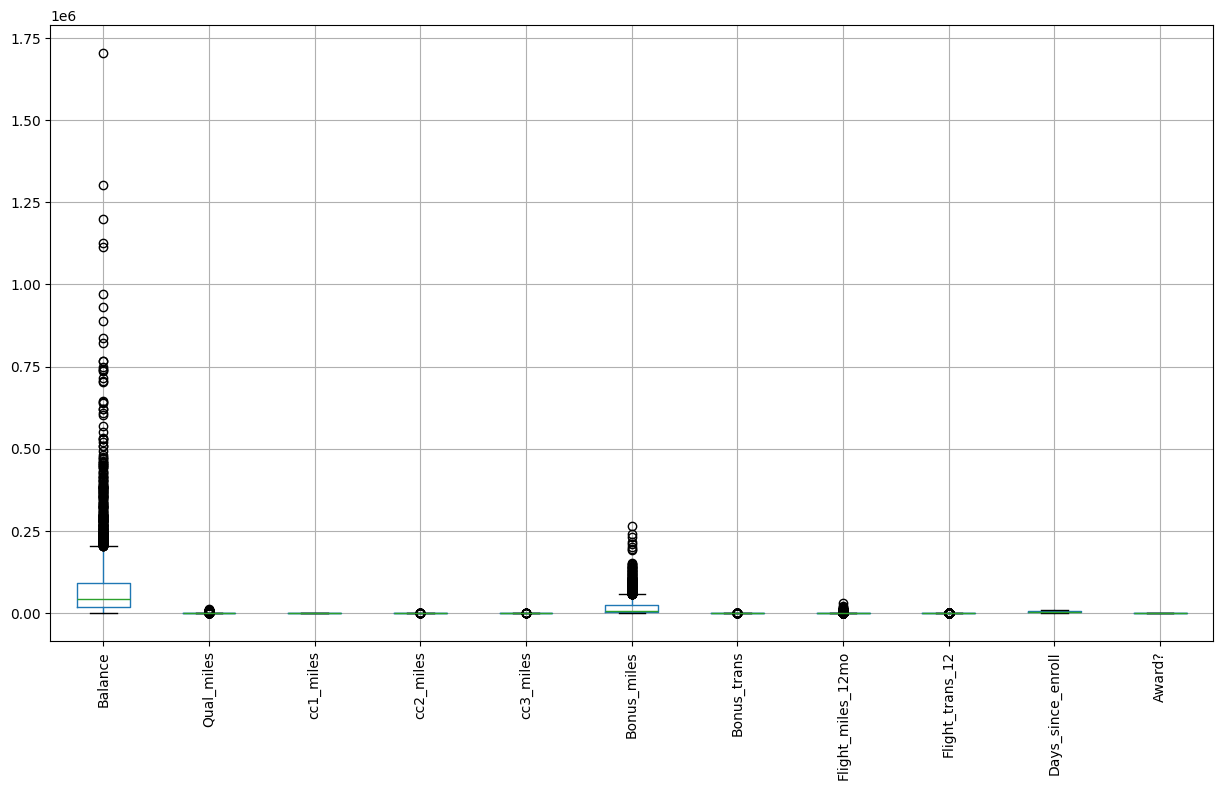

In [ ]:
#boxplot
plt.figure(figsize=(15,8))
df.boxplot(rot=90)
plt.show()

In [ ]:
#outlier capping
def outlier_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[column]= df[column].apply(lambda x:lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x )
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

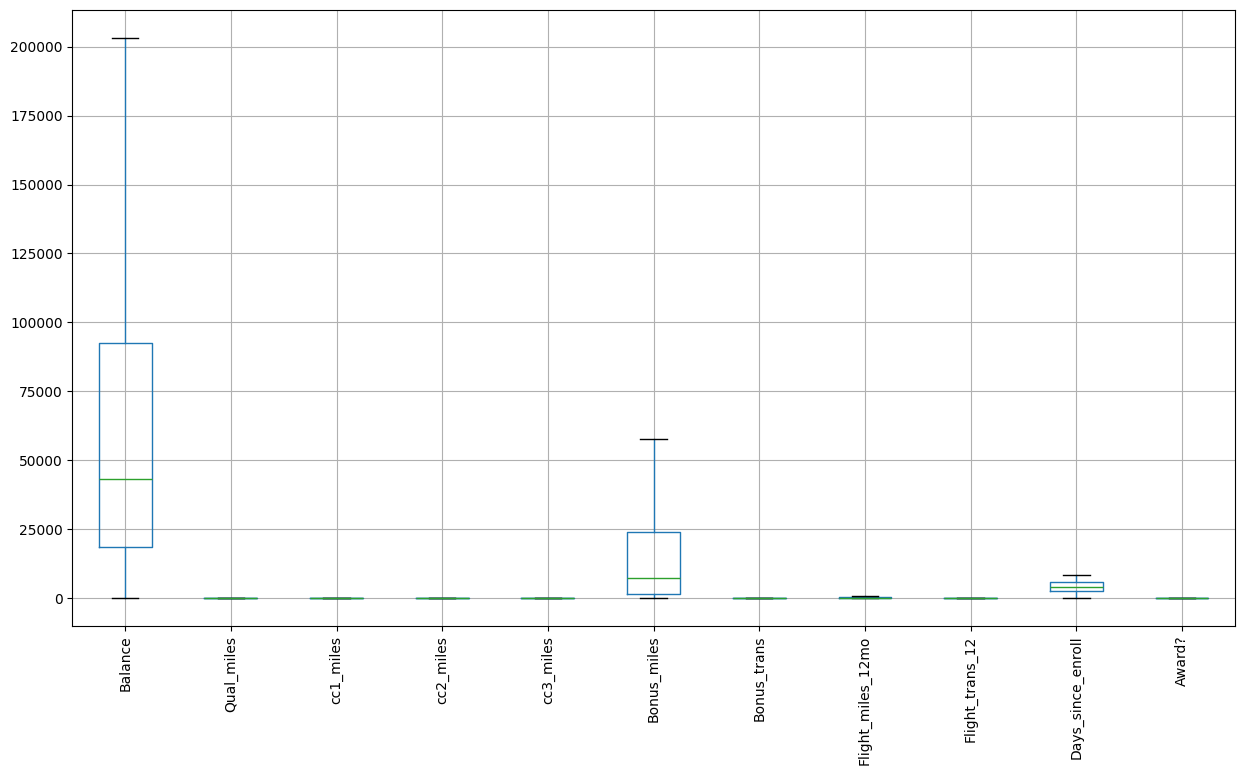

In [ ]:
#boxplot
plt.figure(figsize=(15,8))
df.boxplot(rot=90)
plt.show()

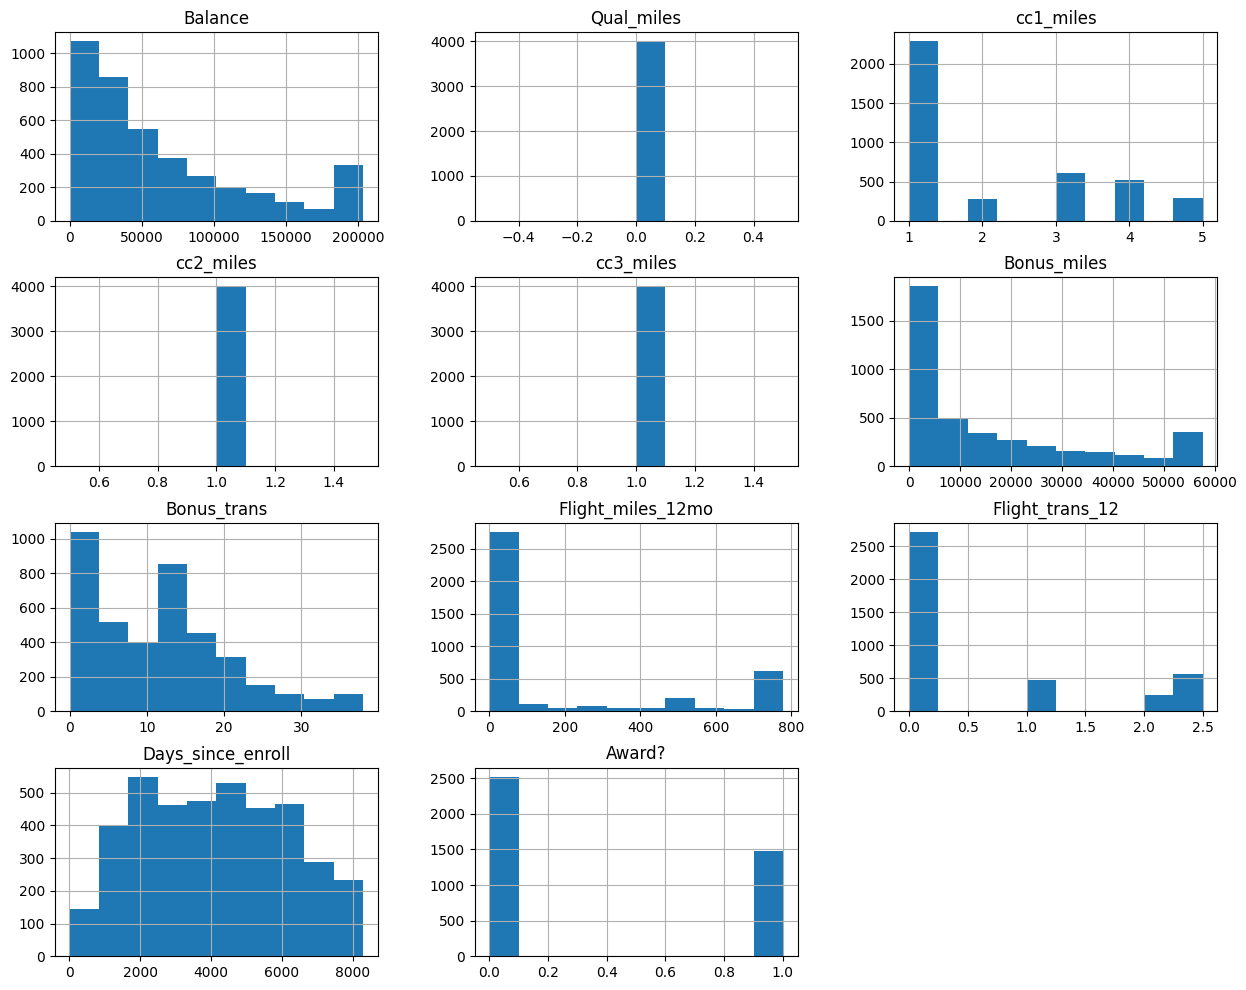

In [ ]:
#histogram
df.hist(figsize=(15,12))
plt.show()

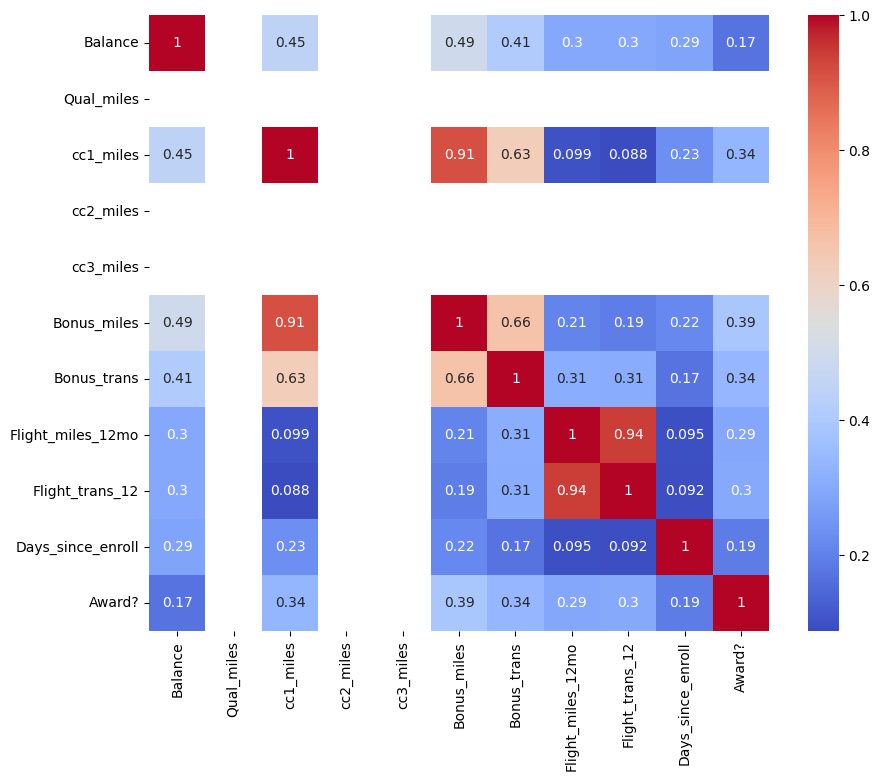

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),annot=True,cmap='coolwarm')

plt.show()

In [ ]:
#Feature Scaling
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled_data,columns=df.columns)

scaled_df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-0.607258,0.0,-0.769578,0.0,0.0,-0.843091,-1.148854,-0.604313,-0.626143,1.395454,-0.766919
1,-0.758947,0.0,-0.769578,0.0,0.0,-0.840822,-1.039133,-0.604313,-0.626143,1.379957,-0.766919
2,-0.382070,0.0,-0.769578,0.0,0.0,-0.624581,-0.819689,-0.604313,-0.626143,1.411920,-0.766919
3,-0.835106,0.0,-0.769578,0.0,0.0,-0.825052,-1.148854,-0.604313,-0.626143,1.372208,-0.766919
4,0.579265,0.0,1.409471,0.0,0.0,1.543191,1.594189,2.034489,2.020176,1.363975,1.303918


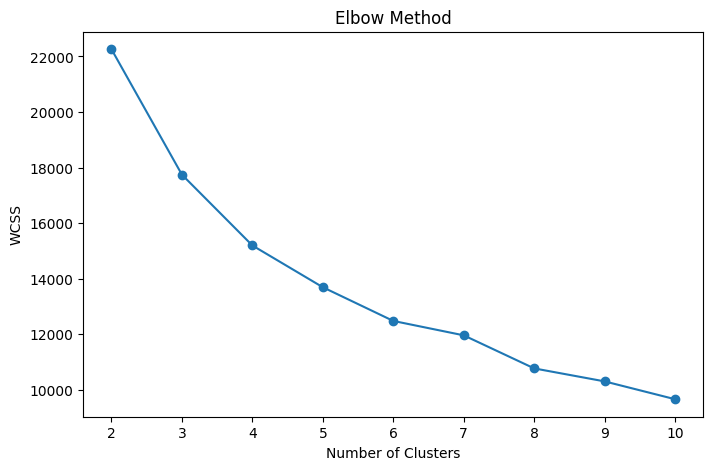

In [ ]:
#Elbow Method
wcss=[]

for i in range(2,11):

    kmeans=KMeans(n_clusters=i,random_state=42)

    kmeans.fit(scaled_df)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(2,11),wcss,marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [ ]:
#K-Means
kmeans = KMeans(n_clusters=4,random_state=42)

kmeans_labels = kmeans.fit_predict(scaled_df)

scaled_df['KMeans_Cluster'] = kmeans_labels

scaled_df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_Cluster
0,-0.607258,0.0,-0.769578,0.0,0.0,-0.843091,-1.148854,-0.604313,-0.626143,1.395454,-0.766919,3
1,-0.758947,0.0,-0.769578,0.0,0.0,-0.840822,-1.039133,-0.604313,-0.626143,1.379957,-0.766919,3
2,-0.382070,0.0,-0.769578,0.0,0.0,-0.624581,-0.819689,-0.604313,-0.626143,1.411920,-0.766919,3
3,-0.835106,0.0,-0.769578,0.0,0.0,-0.825052,-1.148854,-0.604313,-0.626143,1.372208,-0.766919,3
4,0.579265,0.0,1.409471,0.0,0.0,1.543191,1.594189,2.034489,2.020176,1.363975,1.303918,2


**K-Means Insights**

• K-Means grouped airline customers into different clusters based on similar travel patterns.

• Customers within the same cluster have similar mileage, flight frequency, and award usage.

• The Elbow Method helped determine an appropriate number of clusters, and the silhouette score indicates good clustering quality.

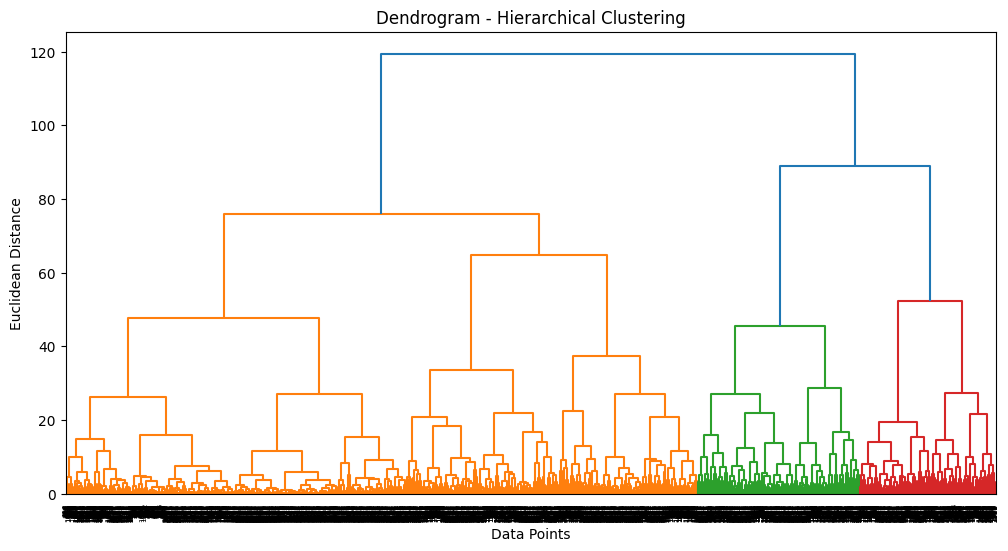

In [ ]:
# Hierarchical Clustering - Dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

plt.figure(figsize=(12, 6))
linked = linkage(scaled_df.drop(['KMeans_Cluster'], axis=1), method='ward')
dendrogram(linked)
plt.title("Dendrogram - Hierarchical Clustering")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

In [ ]:
# Agglomerative Clustering
hc = AgglomerativeClustering(n_clusters=4)
hc_labels = hc.fit_predict(scaled_df.drop(['KMeans_Cluster'], axis=1))
scaled_df['HC_Cluster'] = hc_labels


In [ ]:
# Silhouette Score
hc_score = silhouette_score(scaled_df.drop(['KMeans_Cluster','HC_Cluster'], axis=1), hc_labels)
print("Hierarchical Clustering Silhouette Score:", hc_score)


Hierarchical Clustering Silhouette Score: 0.20256214455852284


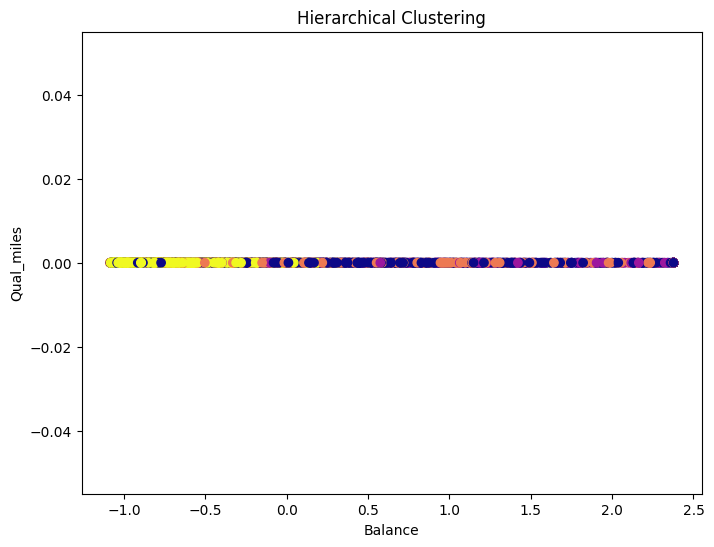

In [ ]:
# Visualization
plt.figure(figsize=(8,6))
plt.scatter(scaled_df.iloc[:,0], scaled_df.iloc[:,1], c=hc_labels, cmap='plasma')
plt.title("Hierarchical Clustering")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.show()

In [ ]:
#Silhouette Score
score = silhouette_score(scaled_df.drop('KMeans_Cluster',axis=1),kmeans_labels)

print("Silhouette Score :",score)

Silhouette Score : 0.2978174647403042


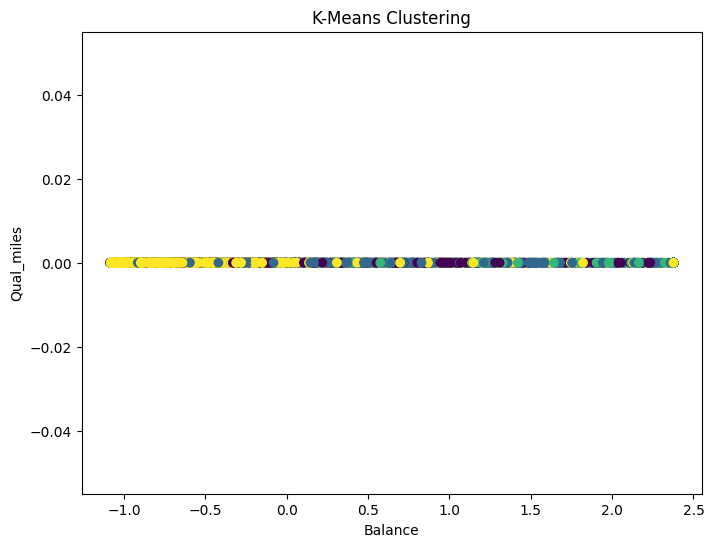

In [ ]:
#K-Means Visualization
plt.figure(figsize=(8,6))

plt.scatter(scaled_df.iloc[:,0],
            scaled_df.iloc[:,1],
            c=kmeans_labels,
            cmap='viridis')

plt.title("K-Means Clustering")

plt.xlabel(df.columns[0])

plt.ylabel(df.columns[1])

plt.show()

In [ ]:
#DBSCAN
dbscan = DBSCAN(eps=1.5,min_samples=5)

db_labels = dbscan.fit_predict(scaled_df.drop('KMeans_Cluster',axis=1))

scaled_df['DBSCAN_Cluster'] = db_labels

scaled_df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_Cluster,HC_Cluster,DBSCAN_Cluster
0,-0.607258,0.0,-0.769578,0.0,0.0,-0.843091,-1.148854,-0.604313,-0.626143,1.395454,-0.766919,3,3,0
1,-0.758947,0.0,-0.769578,0.0,0.0,-0.840822,-1.039133,-0.604313,-0.626143,1.379957,-0.766919,3,3,0
2,-0.382070,0.0,-0.769578,0.0,0.0,-0.624581,-0.819689,-0.604313,-0.626143,1.411920,-0.766919,3,3,0
3,-0.835106,0.0,-0.769578,0.0,0.0,-0.825052,-1.148854,-0.604313,-0.626143,1.372208,-0.766919,3,3,0
4,0.579265,0.0,1.409471,0.0,0.0,1.543191,1.594189,2.034489,2.020176,1.363975,1.303918,2,1,1


In [ ]:
#DBSCAN Silhouette Score
labels = scaled_df['DBSCAN_Cluster']

if len(set(labels))>1 and -1 in labels:

    mask = labels!=-1

    score = silhouette_score(
        scaled_df.drop(['KMeans_Cluster','DBSCAN_Cluster'],axis=1)[mask],
        labels[mask]
    )

    print(score)

else:

    print("Silhouette Score cannot be calculated")

Silhouette Score cannot be calculated


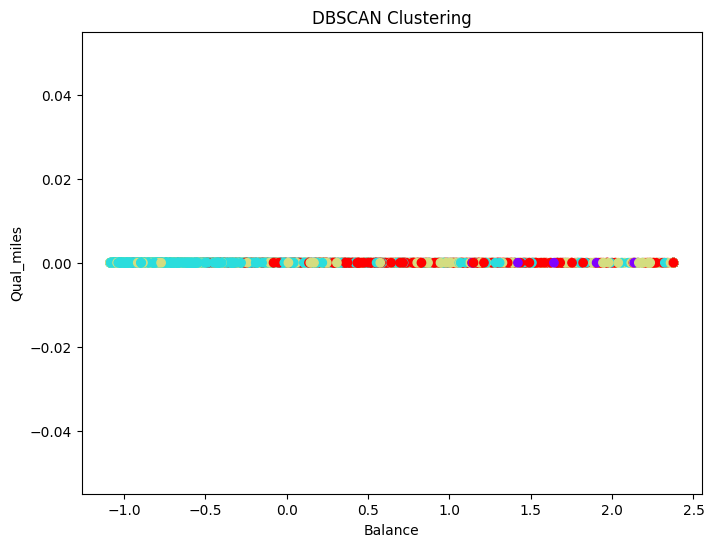

In [ ]:
#DBSCAN Visualization
plt.figure(figsize=(8,6))

plt.scatter(scaled_df.iloc[:,0],
            scaled_df.iloc[:,1],
            c=scaled_df['DBSCAN_Cluster'],
            cmap='rainbow')

plt.title("DBSCAN Clustering")

plt.xlabel(df.columns[0])

plt.ylabel(df.columns[1])

plt.show()

**DBSCAN Insights**

• DBSCAN identified dense groups of customers and detected outliers as noise.

• It is useful for finding clusters with irregular shapes and identifying unusual customer records.

• The clustering quality depends on the selected values of epsilon (eps) and minimum samples (min_samples).

In [ ]:
#Cluster Analysis
print("KMeans Cluster Counts")

print(scaled_df['KMeans_Cluster'].value_counts())

print()

print("DBSCAN Cluster Counts")

print(scaled_df['DBSCAN_Cluster'].value_counts())

KMeans Cluster Counts
KMeans_Cluster
3    1903
1    1078
0     617
2     401
Name: count, dtype: int64

DBSCAN Cluster Counts
DBSCAN_Cluster
 0    1959
 1    1464
 2     543
-1      33
Name: count, dtype: int64


**conclusion** : K-Means and DBSCAN were successfully implemented on the EastWest Airlines dataset. The data was preprocessed, scaled, and analyzed using clustering techniques. K-Means produced well-defined customer groups, while DBSCAN effectively detected outliers. The silhouette score was used to evaluate clustering quality, and both algorithms provided meaningful insights into customer segmentation.